In [2]:
# %%

from pathlib import Path
import sys
import importlib

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.data_loading as exio
import src.analysis_tools as at
import seaborn as sns
import importlib
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
import seaborn as sns
import src.stimuli_timeline as st
import src.plotting as plott
import src.data_loading as exio
import src.analysis_tools as at
import importlib
import src.plotting as plott
importlib.reload(plott)



<module 'src.plotting' from 'c:\\Users\\larsch-lab\\code\\social_filters\\src\\plotting.py'>

In [3]:
# %%
### ==== CONFIG GENERAL (común a todos los peces) ===============================

experiment_name = "Exp_3_rocking_2"#"Exp_4_radius"#"Exp_2_rocking_1" #
main_path = Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p")
analysis_path= Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Analysis")
stimuli_main_path = analysis_path
save_path= analysis_path / experiment_name / "plots"

fps_2p = 2.0
selected_blocks = [f"B{n}" for n in range(1, 5)]

t_pre_s  = 5.0   # time before onset to include
t_post_s = 32.0  # time after onset to include

# Lista de peces que quieres procesar
fish_ids = [
"L588_f01", # botton left
#"L588_f02", #top-right
"L588_f03", # botton left
"L654_f01", # botton left
"L654_f03" # botton left
]

importlib.reload(exio)
importlib.reload(at)

def load_and_align_one_fish(
    fish_id: str,
    experiment_name: str,
    main_path: Path,
    stimuli_main_path: Path,
    fps_2p: float,
    selected_blocks,
    t_pre_s: float,
    t_post_s: float,
):
    """Carga un experimento de un pez y calcula las trial-aligned traces.
    Devuelve TODO lo que quieres para usar después.
    """
    # ==== LOAD EVERYTHING IN ONE GO =========================================
    results = exio.load_2p_experiment(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
    )

    dfof              = results["dfof"]
    stimuli_trace_60  = results["stimuli_trace_60"]
    stimuli_id_map    = results["stimuli_id_map"]
    raster            = results["raster"]
    dfof_center       =results["deltaF_center"]
    dFoF_merged_map    =   results["dFoF_merged_map"]
    stimuli_durations = results["stimuli_durations"]
    kept_neuron_indices = results["kept_neuron_indices"]
    z_traces = results["z_traces"]
        # NEW: normalizar dfof_center a [0, 1] globalmente
    min_val = np.nanmin(dfof_center)          # NEW
    max_val = np.nanmax(dfof_center)          # NEW
    rng = max_val - min_val + 1e-12           # NEW (evita división por cero)

    dfof_center_norm = (dfof_center - min_val) / rng   # NEW


    # ==== BUILD TRIAL-ALIGNED TRACES ========================================
    res = at.build_trial_aligned_traces(
        dfof=dfof,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )



    # ==== BUILD TRIAL-ALIGNED TRACES Signf========================================
    res_raster = at.build_trial_aligned_traces(
        dfof=raster,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    # ==== BUILD TRIAL-ALIGNED Z-core =======================================
    res_zcore = at.build_trial_aligned_traces(
        dfof=z_traces,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    ##==== BUILD TRIAL-ALIGNED Norm_Df/F========================================

    res_norm = at.build_trial_aligned_traces(
        dfof=dfof_center_norm,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    return {
        "trial_aligned_traces": res["trial_aligned_traces"],  # dict: stim_id -> (n_neurons, n_trials, frames)
        "stimuli_ids":          res["stimuli_ids"],           # list
        "stimuli_names":        res["stimuli_names"],         # list
        "win_length":           res["win_length"],            # int
        "stimuli_trace":        res["stimuli_trace"],         # (n_frames_total,)
        "onsets_by_id":         res["onsets_by_id"],          # dict: stim_id -> (n_trials,)
        "trial_aligned_traces_raster": res_raster["trial_aligned_traces"],
        "trial_aligned_traces_norm": res_norm["trial_aligned_traces"],
        "trial_aligned_traces_z_core": res_zcore["trial_aligned_traces"],
        # row data
        "dfof":                  dfof,
        "raster":                raster,
        "dfof_center":           dfof_center,
        "dFoF_merged_map":       dFoF_merged_map,
        "stimuli_durations":     stimuli_durations,
        "kept_neuron_indices":   kept_neuron_indices,
        "stimuli_id_map":         stimuli_id_map,
        # si más tarde quieres acceder a cosas del results original:
        "meta": {
            "frames_per_block":       results["frames_per_block"],
            "duration_2p_block_sec":  results["duration_2p_block_sec"],
            "paths":                  results["paths"],
            "plane_ids":              results["plane_ids"],
            "stat_per_plane":         results["stat_per_plane"],
            # etc, añade aquí lo que te haga falta
        }
    }


# ==== PROCESAR TODOS LOS PECES ==============================================
all_fish_data = {}

for fish_id in fish_ids:
    print(f"\n=== Procesando pez {fish_id} ===")
    all_fish_data[fish_id] = load_and_align_one_fish(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
    )

print("Listo, todos los peces procesados.")



=== Procesando pez L588_f01 ===
Loaded significant traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L588_f01_Exp_3_rocking_2\03_analysis\functional\plots\significant_traces\L588_f01_significant_traces.npz
Loaded kept_neuron_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L588_f01_Exp_3_rocking_2\03_analysis\functional\plots\filtered_neurons_by_stimuli\L588_f01_kept_neuron_indices.npy
Loaded filtered_roi_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L588_f01_Exp_3_rocking_2\03_analysis\functional\suite2P\merged_dFoF\L588_f01_dFoF_merged_filtered_roi_indices.npy
Loaded z_traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L588_f01_Exp_3_rocking_2\03_analysis\functional\plots\z_core\L588_f01_zcore.npz
Using canonical merged map file: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L588_f01_Exp_3_rocking_2\03_analysis\functional\suite2P\merged_dFoF\L588_f01_dFoF_m

In [4]:

# select colors and linestyles for stimuli
# --- Set A (default)

colors_C = {
    'RiB': sns.color_palette('dark:#404040', 10)[7],
    'LeB': sns.color_palette('dark:#404040', 10)[7],
    'Ri1F': sns.color_palette('Blues', 8)[7],
    'Ri2F': sns.color_palette('Greens', as_cmap=True)(0.4),
    'DRiF': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'Le1F': sns.color_palette('Blues', 8)[7],
    'Le2F': sns.color_palette('Greens', as_cmap=True)(0.4),
    'DLeF': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'BiF1': sns.color_palette('Reds', as_cmap=True)(0.9),
    'BiF2': sns.color_palette('Reds', as_cmap=True)(0.9),
    'RiR': sns.color_palette('Greens', as_cmap=True)(0.9),
    'LeR': sns.color_palette('Greens', as_cmap=True)(0.9),
    'BiR1': sns.color_palette('PuRd', as_cmap=True)(0.6),
    'BiR2': sns.color_palette('PuRd', as_cmap=True)(0.6),

}
linestyles_C = {
    'RiB': '--',
    'Ri1F': '--',
    'Ri2F': '--',
    'DRiF': '--',
    'BiF1': '--',
    'RiR': '--',
    'BiR1': '--',
}

stimuli_colors = colors_C
stimuli_linestyles = linestyles_C

# --- choose stimulus-aligned windows ---
window_pre = 5  # seconds before stimulus
window_post = 17  # seconds after stimulus

stimuli_ordered = ['RiB',
                   'LeB',
                   'Ri1F',
                   'Ri2F',
                   'DRiF',
                   'Le1F',
                   'Le2F',
                   'DLeF',
                   'BiF1',
                   'BiF2',
                   'RiR',
                   'LeR',
                   'BiR1',
                   'BiR2',

                   ]
print("Using colors for:", experiment_name)
print(stimuli_linestyles)

Using colors for: Exp_3_rocking_2
{'RiB': '--', 'Ri1F': '--', 'Ri2F': '--', 'DRiF': '--', 'BiF1': '--', 'RiR': '--', 'BiR1': '--'}


In [5]:
import sys

print(sys.version)
print(sys.executable)

3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)]
c:\ProgramData\miniconda3\envs\social_filters\python.exe


In [6]:
from src.multifish_analysis import (
    combine_reps_one_stim,
    build_matrix_for_fish,
    build_matrix_all_fish,
)

In [7]:
fish_id = fish_ids[1]
trial_aligned_traces = all_fish_data[fish_id]["trial_aligned_traces"]
stimuli_id_map = all_fish_data[fish_id]["stimuli_id_map"]
stimuli_durations = all_fish_data[fish_id]["stimuli_durations"]
stimuli_ids = all_fish_data[fish_id]["stimuli_ids"]
stimuli_names = all_fish_data[fish_id]["stimuli_names"]
stimuli_durations = all_fish_data[fish_id]["stimuli_durations"]
onsets_by_id = all_fish_data[fish_id]["onsets_by_id"]


Final matrix shape: (1687, 4144)


Final matrix shape: (1347, 148)
✅ Saved: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Analysis\Exp_3_rocking_2\plots\L588_f03_dfof_as_func_of_time_pca.png


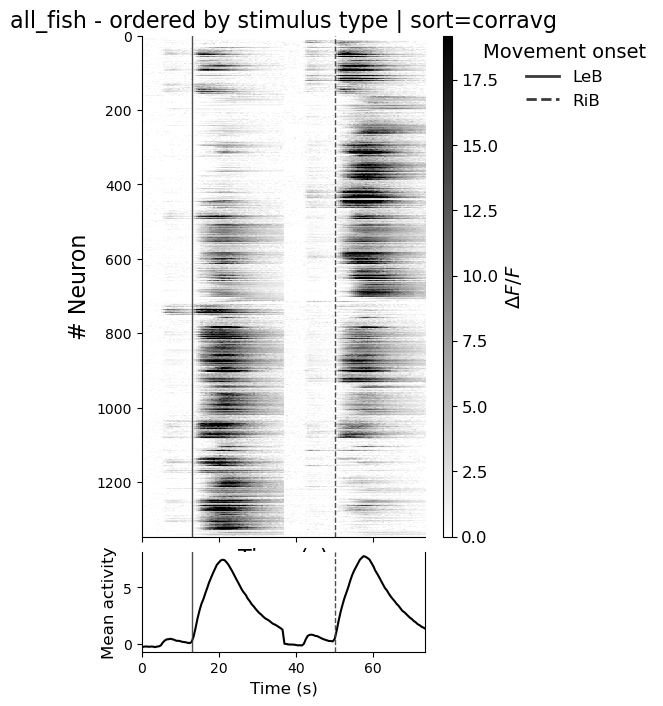

In [8]:
# plot all fish together
#{'BiF1': 1, 'BiF2': 2, 'BiR1': 3, 'BiR2': 4, 'DLeF': 5, 'DRiF': 6, 'Le1F': 7, 'Le2F': 8, 'LeB': 9, 'LeR': 10, 'Ri1F': 11, 'Ri2F': 12, 'RiB': 13, 'RiR': 14}

#stim_order = [13,11,12,6,1,14,3]
stim_order = [9,13]
combine_mode = "mean"  # mean or concat
trace_type =  "zscore" #  "dfof" ,  "raster" , zscore" -> trial_aligned_traces
M_all = build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode, trace_type=trace_type)
print("Final matrix shape:", M_all.shape)

# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)
flat_matrix_all_fish = M_all  # (time, neurons) for raster_with_stimuli


fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='corravg',      # or "pca", "hier", etc.
    n_clusters=3,
    random_state=0,
    neuron_order=None,       # or pass your own `neuron_order`
    sort_label=None,         # optional label override
    is_binary=False,         # True if you pass a 0/1 significance matrix
    show_mean_trace=True,
    figsize=(4, 8),
    fish_id="all_fish",
)


save_path.mkdir(parents=True, exist_ok=True)
out_png = save_path / f"{fish_id}_dfof_as_func_of_time_pca.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
print("✅ Saved:", out_png)


In [33]:
## i just use the same funtons and run per fish to generate a bigger matrix...

In [9]:
## Organize by Left and Rigth response....
## First Concatenate mean traces across experiments
import numpy as np

# result: concat_mean_traces[stim] -> (sum_fish n_kept_neurons_fish, win_length)
concat_mean_traces = {stim: [] for stim in stimuli_ids}
concat_mean_all_neurons = {stim: [] for stim in stimuli_ids}
concat_mean_all_neurons_norm = {stim: [] for stim in stimuli_ids}

for fid in fish_ids:
    trial_aligned_traces = all_fish_data[fid]["trial_aligned_traces"]
    trial_aligned_traces_norm = all_fish_data[fid]["trial_aligned_traces_norm"]
    kept_neuron_indices = all_fish_data[fid]["kept_neuron_indices"]

    for stim in stimuli_ids:
        X = trial_aligned_traces[stim]              # (n_neurons, win_length, n_trials)
        Xkept = X[kept_neuron_indices, :, :]        # (n_kept_fish, win_length, n_trials)
        mean_trace = np.nanmean(Xkept, axis=2)     # (n_kept_fish, win_length)
        mean_all_neurons = np.nanmean(mean_trace, axis=0)

        concat_mean_traces[stim].append(mean_trace)
        concat_mean_all_neurons[stim].append(mean_all_neurons)

        Y = trial_aligned_traces_norm[stim]        # same as X but Global Norm
        mean_trace_norm = np.nanmean(Y, axis=2)
        mean_all_neurons_norm = np.nanmean(mean_trace_norm, axis=0)

        concat_mean_all_neurons_norm[stim].append(mean_all_neurons_norm)
# stack per stimulus along the neuron axis
for stim in stimuli_ids:
    concat_mean_traces[stim] = np.vstack(concat_mean_traces[stim])
    concat_mean_all_neurons[stim] = np.vstack(concat_mean_all_neurons[stim])
    concat_mean_all_neurons_norm[stim] = np.vstack(concat_mean_all_neurons_norm[stim])
# Example:
# big_mat_FL1 = concat_mean_traces['FL1']   # shape: (all_kept_neurons_all_fish, win_length)
print(concat_mean_all_neurons[stim].shape)
print(concat_mean_traces[stim].shape)

(4, 74)
(1347, 74)


In [10]:
pre_frames  = int(round(t_pre_s * fps_2p))
post_frames = int(round(t_post_s * fps_2p))
win_lenght = pre_frames + post_frames
frame_window = (pre_frames, win_lenght)
L, R, TI = at.compute_left_right_index(
    mean_traces=concat_mean_traces,
    left_stim=9,   # e.g., FLB = 4
    right_stim=13,
    frame_window=frame_window,
    kept_cells=None,   # or None
)

RL_neuro_order= np.argsort(TI)

In [11]:
print(flat_matrix_all_fish.shape)

(1347, 148)


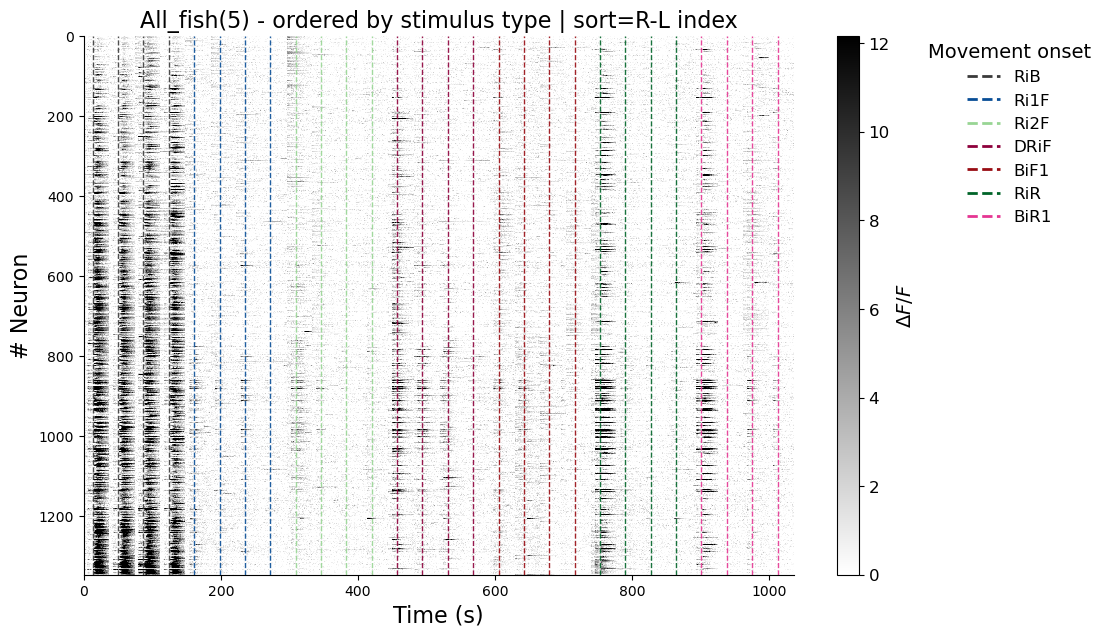

In [12]:
# plot all fish together
#{'BiF1': 1, 'BiF2': 2, 'BiR1': 3, 'BiR2': 4, 'DLeF': 5, 'DRiF': 6, 'Le1F': 7, 'Le2F': 8, 'LeB': 9, 'LeR': 10, 'Ri1F': 11, 'Ri2F': 12, 'RiB': 13, 'RiR': 14}

stim_order = [13,11,12,6,1,14,3]
combine_mode = "concat"  # mean or concat
trace_type =  "zscore" #  "dfof" ,  "raster" , zscore" -> trial_aligned_traces
M_all = build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode, trace_type=trace_type)
flat_matrix_all_fish = M_all   # (time, neurons) for raster_with_stimuli

fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='pca',      # or "pca", "hier", etc.
    n_clusters=3,
    random_state=0,
    neuron_order=RL_neuro_order,
    show_mean_trace=False,# or pass your own `neuron_order`
    sort_label='R-L index',         # optional label override
    is_binary=False,         # True if you pass a 0/1 significance matrix
    figsize=(10, 7),
    fish_id="All_fish(5)",
)

# save_path.mkdir(parents=True, exist_ok=True)
# if is_raster is False:
#     out_png = save_path / f"delta_as_func_of_time_just_bouts_average.png"
# else:
#    out_png = save_path / f"binary_as_func_of_time_just_bouts_average.png"
# fig.savefig(out_png, dpi=600, bbox_inches="tight")
# print("✅ Saved:", out_png)

new_stimuli_ids:   [13, 11, 12, 6, 1, 14, 3]
new_stimuli_names: ['RiB', 'Ri1F', 'Ri2F', 'DRiF', 'BiF1', 'RiR', 'BiR1']
shape of first M: (4, 74)


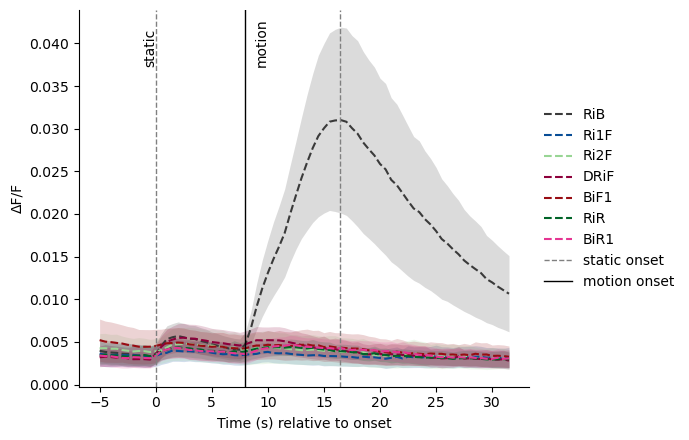

In [13]:
#### identify if
#Stimuli IDs: [1, 2, 3, 4, 5, 6, 7, 8]
#Stimuli names: ['LBb', 'LBc', 'LBd', 'LB', 'RBb', 'RBc', 'RBd', 'RB']
stim_order = [4,1,2,3,8,5,6,7]


#{'LB': 1, 'RB': 2, 'RL1': 3, 'RL2': 4, 'RL3': 5, 'RLR1': 6, 'RLR2': 7, 'RR1': 8, 'RR2': 9, 'RR3': 10}

#stimuli_wanted = [0,1,2,3,4,7,8,9,5,6]  # positions in the list (0-based!)
stimuli_wanted = [12,10,11,5,0,13,2]## rigth
# stimuli_wanted = [4,1,2,3] ## left
M = {}  # new dict with selected mean_traces
new_stimuli_ids = []  # new list of ids
new_stimuli_names = []  # new list of names

for pos in stimuli_wanted:
    # id in your list at that position
    stim_id = stimuli_ids[pos]
    stim_name = stimuli_names[pos]

    # take the correct array from the dict
    M[stim_id] = concat_mean_all_neurons[stim_id]

    # store id and name in new lists
    new_stimuli_ids.append(stim_id)
    new_stimuli_names.append(stim_name)

print("new_stimuli_ids:  ", new_stimuli_ids)
print("new_stimuli_names:", new_stimuli_names)
# example: check one of the matrices
print("shape of first M:", M[new_stimuli_ids[0]].shape)


fig, ax, used_colors, out_path = plott.plot_stimulus_means(
    mean_traces=M,
    stimuli_ids=new_stimuli_ids,
    stimuli_names=new_stimuli_names,
    title_prefix="",
    fps_2p=fps_2p,
    t_post_s=t_post_s,
    t_pre_s=t_pre_s,
    stimuli_durations= stimuli_durations,
    plots_path=None,       # Path object or str
    prefix=None,               # e.g., "exp12_mouseA"
    dpi=600,
    save=False,
    stimuli_colors=stimuli_colors,            # <— pass styles here
    stimuli_linestyles=stimuli_linestyles,
    close_after=False,
    kept_cells = None,
    comment="jhghjg" # for saving
)

